In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [2]:
import sys

sys.path.append('../../scripts')

In [3]:
from helpers import _normalize_counts, safe_log2_fold_change, compute_correlations, subsample_adata

In [4]:
import numpy as np
import scanpy as sc
import anndata as ad
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt

from tqdm import tqdm
from sklearn.model_selection import train_test_split

from cellina import Cellina as CellinaModel
from utils import set_seed
from train_loo import preprocess_adata

In [5]:
plt.rcParams['font.family'] = 'monospace'
plt.rcParams['font.size'] = 16
plt.rcParams['figure.dpi'] = 50


In [6]:
import cellina
cellina.__version__

'0.99.3'

# Get dataset

In [7]:
set_seed(0)

In [8]:
slide_id = 'crc_210'

In [9]:
data_path = f"/data/a330d/datasets/crc/raw_zenodo/{slide_id}.h5ad"
adata = sc.read(data_path)
adata.obs_names_make_unique()

In [10]:
adata = preprocess_adata(adata, n_neighbors=20)

/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/scanpy/preprocessing/_simple.py:165: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs["n_counts"] = number


In [11]:
adata

AnnData object with n_obs × n_vars = 552241 × 2000
    obs: 'fov', 'Area', 'AspectRatio', 'CenterX_local_px', 'CenterY_local_px', 'Width', 'Height', 'Mean.PanCK', 'Max.PanCK', 'Mean.CD68_CK8_18', 'Max.CD68_CK8_18', 'Mean.CD298_B2M', 'Max.CD298_B2M', 'Mean.CD45', 'Max.CD45', 'Mean.DAPI', 'Max.DAPI', 'cell_id', 'Dash', 'ISH.concentration', 'Panel', 'Run_Tissue_name', 'Run_name', 'assay_type', 'dualfiles', 'tissue', 'version', 'slide_ID', 'CenterX_global_px', 'CenterY_global_px', 'cell_ID', 'unassignedTranscripts', 'median_RNA', 'RNA_quantile_0.75', 'RNA_quantile_0.8', 'RNA_quantile_0.85', 'RNA_quantile_0.9', 'RNA_quantile_0.95', 'RNA_quantile_0.99', 'nCount_RNA', 'nFeature_RNA', 'median_negprobes', 'negprobes_quantile_0.75', 'negprobes_quantile_0.8', 'negprobes_quantile_0.85', 'negprobes_quantile_0.9', 'negprobes_quantile_0.95', 'negprobes_quantile_0.99', 'nCount_negprobes', 'nFeature_negprobes', 'median_falsecode', 'falsecode_quantile_0.75', 'falsecode_quantile_0.8', 'falsecode_quantile

In [12]:
labels_key = 'coarse_type'
domains_key = 'typ_clean'
batch_key = 'sid'

In [13]:
fig_save_path = "../../figures/application"

... storing 'typ_clean' as categorical


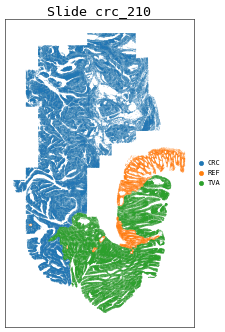

In [14]:
fig, ax = plt.subplots(figsize=(8, 8))  # width x height in inches

sc.pl.spatial(
    adata,
    color=domains_key,
    ax=ax,
    spot_size=100,
    title=f"Slide {slide_id}",
    show=False,
)
# Remove x and y axis labels
ax.set_xlabel('')
ax.set_ylabel('')

# Optionally, remove ticks too
ax.set_xticks([])
ax.set_yticks([])
plt.show()

fig.savefig(f"{fig_save_path}/{slide_id}slide.png", bbox_inches='tight')

## Data splits

In [15]:
split = "random"

# Get holdout indices
if split == "random":
    fraction = 0.1
    n_cells = adata.n_obs
    n_holdout = int(n_cells * fraction)

    # Randomly choose cells
    test_idx = np.random.choice(n_cells, n_holdout, replace=False)

elif split == "ood":
    holdout_ct = "Fibroblast"
    is_tumor_region  = adata.obs[domains_key].str.contains("CRC", regex=True)
    is_holdout_ct = adata.obs[labels_key] == holdout_ct

    # Combine for test set
    test_mask = (is_tumor_region) & (is_holdout_ct)
    test_idx = np.where(test_mask)[0]
else:
    raise ValueError(f"Unknown split: {split}")

# Get train/val indices
all_idx = np.arange(adata.n_obs)
trainval_idx = np.setdiff1d(all_idx, test_idx)

In [16]:
# Set 'is_holdout' to False by default, then True for selected cells
adata.obs['is_holdout'] = False
adata.obs.iloc[test_idx, adata.obs.columns.get_loc('is_holdout')] = True

In [17]:
validation_size = 0.1
train_idx, val_idx = train_test_split(
    trainval_idx,
    test_size=validation_size,
    random_state=0,
    shuffle=True,
)

# Train

In [18]:
model_base_path = f"./{slide_id}"

In [19]:
batch_size = 2048

In [20]:
from scvi.train._callbacks import SaveCheckpoint, EarlyStopping

model_args = {
    'adata': adata,
    'n_latent': 64,
    'n_layers': 2,
    'use_observed_lib_size': True,
    'condition_on_intrinsic': False,
    'gene_likelihood': 'nb',
    'classifier_lambda': 1.,
    'discriminator_lambda': 1.,
    # 'num_neighbors': [-1],
    }
train_args = {'max_epochs': 100,
              'batch_size': batch_size,
              'check_val_every_n_epoch': 1,
              'early_stopping': True,
              'devices': [0],
              'datasplitter_kwargs': {
                  "external_indexing": [train_idx, val_idx, test_idx],
                  },
              'enable_checkpointing':True,
              'callbacks': [
                  SaveCheckpoint(
                      monitor='vae_loss_validation',
                      dirpath=f"{model_base_path}",
                      load_best_on_end=True,
                      ),
                  EarlyStopping(
                      monitor="vae_loss_validation",
                      patience=5,
                      mode="min",
                    ),
                ],
    }

plan_kwargs = {
    'lr': 1e-3,
    'normalize_losses': True
    }

In [21]:
CellinaModel.setup_anndata(adata,
                           batch_key=batch_key,
                           labels_key=labels_key, 
                           domains_key=domains_key, 
                           spatial_obsm_key="spatial_x",
                           layer='counts')

INFO     Generating sequential column names                                                                        


/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


In [22]:
model = CellinaModel(
    **model_args, 
)
model.train(**train_args, plan_kwargs=plan_kwargs)

INFO     cellina: The Cellina model has been initialized with adversarial domain forgetting                        


INFO: GPU available: True (cuda), used: True
2026-06-03 19:57:58 | [INFO] GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
2026-06-03 19:57:58 | [INFO] TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
2026-06-03 19:57:58 | [INFO] HPU available: False, using: 0 HPUs
INFO: You are using a CUDA device ('NVIDIA GeForce RTX 4090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
2026-06-03 19:57:58 | [INFO] You are using a CUDA device ('NVIDIA GeForce RTX 4090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.o

Training:   0%|          | 0/100 [00:00<?, ?it/s]

INFO     File                                                                                                      
         /data/ddimitrov/repos/cellina-reproducibility/notebooks/application/crc_210/epoch=25-step=10950-vae_loss_v
         alidation=304.0638732910156/model.pt already downloaded                                                   


/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/scvi/model/base/_save_load.py:76: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = to

In [23]:
model.history_['validation_loss'].tail()

,validation_loss
epoch,
26,-70.047134
27,-78.107147
28,-66.600899
29,-82.196304
30,-69.440308


# Inference and clustering

In [24]:
# checkpoint_name = os.listdir(f"{model_base_path}")[0]
# model = CellinaModel.load(
#     f"{model_base_path}/{checkpoint_name}",
#     adata=adata,
# )

In [25]:
adata.obsm['cellina_basal'] = model.get_latent_representation(adata=adata, latent_key='z', batch_size=4048)
adata.obsm['cellina_spatial'] = model.get_latent_representation(adata=adata, latent_key='s', batch_size=4048)
# adata.obsm['cellina_latent'] = model.get_latent_representation(adata=adata, batch_size=4048)

### Latent visualization

In [26]:
adata_sub = subsample_adata(adata, fraction=0.5)


In [27]:
sc.pp.neighbors(adata_sub, use_rep='cellina_basal')
sc.tl.umap(adata_sub)

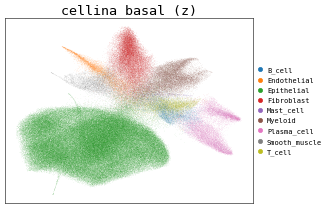

In [28]:
ax = sc.pl.umap(adata_sub, color=[labels_key], wspace=0.3, show=False, title="cellina basal (z)")
# Remove x and y axis labels
ax.set_xlabel('')
ax.set_ylabel('')

# Optionally, remove ticks too
ax.set_xticks([])
ax.set_yticks([])

fig = ax.figure
plt.show()

fig.savefig(f"{fig_save_path}/crc_210_umap_basal_ct.png", bbox_inches='tight')

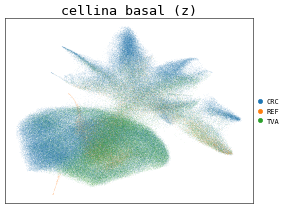

In [29]:
ax = sc.pl.umap(adata_sub, color=[domains_key], wspace=0.3, show=False, title="cellina basal (z)")
# Remove x and y axis labels
ax.set_xlabel('')
ax.set_ylabel('')

# Optionally, remove ticks too
ax.set_xticks([])
ax.set_yticks([])

fig = ax.figure
plt.show()

fig.savefig(f"{fig_save_path}/{slide_id}_umap_basal_niche.png", bbox_inches='tight')

In [30]:
sc.pp.neighbors(adata_sub, use_rep='cellina_spatial')
sc.tl.umap(adata_sub)

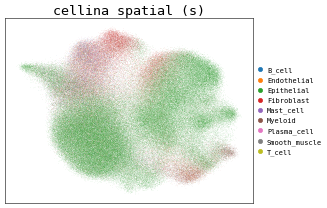

In [31]:
ax = sc.pl.umap(adata_sub, color=[labels_key], wspace=0.3, show=False, title="cellina spatial (s)")
# Remove x and y axis labels
ax.set_xlabel('')
ax.set_ylabel('')

# Optionally, remove ticks too
ax.set_xticks([])
ax.set_yticks([])

fig = ax.figure
plt.show()

fig.savefig(f"{fig_save_path}/{slide_id}_umap_spatial_ct.png", bbox_inches='tight')

In [32]:
palette = {
    # Control
    'REF': '#E69F00',

    # CRC
    'CRC': "#0075D5",

    # TVA
    'TVA': "#00B221",
}

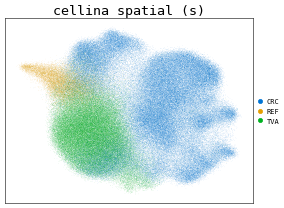

In [33]:
ax = sc.pl.umap(adata_sub, color=[domains_key], wspace=0.3, show=False, title="cellina spatial (s)", palette=palette)
# Remove x and y axis labels
ax.set_xlabel('')
ax.set_ylabel('')

# Optionally, remove ticks too
ax.set_xticks([])
ax.set_yticks([])

fig = ax.figure
plt.show()

fig.savefig(f"{fig_save_path}/{slide_id}_umap_spatial_niche.png", bbox_inches='tight')

## Hotspot clusters

In [34]:
import pandas as pd
import decoupler as dc
import hotspot

from plotting import plot_custom_umap

In [35]:
adata_crc = adata[adata.obs[domains_key].str.contains('CRC')].copy()

In [36]:
set_seed(0)  # ensure reproducible hotspot KNN and module detection

In [37]:
hs = hotspot.Hotspot(
    adata_crc,
    layer_key="counts",
    model='danb',
    latent_obsm_key="cellina_spatial",
    umi_counts_obs_key="nCount_RNA"
)

hs.create_knn_graph(
    weighted_graph=False, n_neighbors=30,
)

In [38]:
hs_results = hs.compute_autocorrelations(jobs=24)

100%|██████████| 2000/2000 [00:08<00:00, 230.88it/s]


In [39]:
# Select the genes with significant lineage autocorrelation
top_k = 1200
hs_genes = hs_results.loc[hs_results.FDR < 0.05].head(top_k).index

In [40]:
# Compute pair-wise local correlations between these genes
load_lcz = False
base_dir = f'../results/analysis/{slide_id}'
lcz_path = f'{base_dir}/hotspot_lcz_crc.csv'

if load_lcz:
    lcz = pd.read_csv(lcz_path, index_col=0)
    hs.local_correlation_z = lcz
else:
    lcz = hs.compute_local_correlations(hs_genes, jobs=24)
    os.makedirs(base_dir, exist_ok=True)
    lcz.to_csv(lcz_path)

Computing pair-wise local correlation on 1200 features...


100%|██████████| 719400/719400 [12:43<00:00, 942.82it/s] 


In [41]:
modules = hs.create_modules(min_gene_threshold=100, core_only=True, fdr_threshold=0.05)

In [42]:
module_scores = hs.calculate_module_scores()

module_scores.head()

Computing scores for 4 modules...


  0%|          | 0/4 [00:00<?, ?it/s]

100%|██████████| 4/4 [00:39<00:00,  9.93s/it]


,1,2,3,4
c_1_1_1,-2.888196,1.512954,8.949783,-1.147812
c_1_1_2,-2.359490,1.629978,5.972951,-0.845249
c_1_1_3,-2.901209,0.341814,7.790255,-0.607869
c_1_1_4,-3.278421,0.628379,8.587805,-0.886319
c_1_1_5,-2.321137,0.551553,7.007880,-0.559475


In [43]:
module_cols = []
for c in module_scores.columns:
    key = f"Module {c}"
    adata_crc.obs[key] = module_scores[c]
    module_cols.append(key)

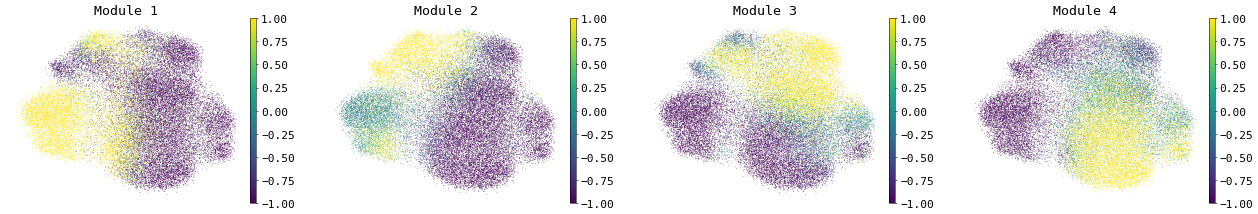

In [44]:
plot_custom_umap(
    adata_crc, subsample=0.1, use_rep='cellina_spatial', color=module_cols,frameon=False, vmin=-1, vmax=1, wspace=0.2
)

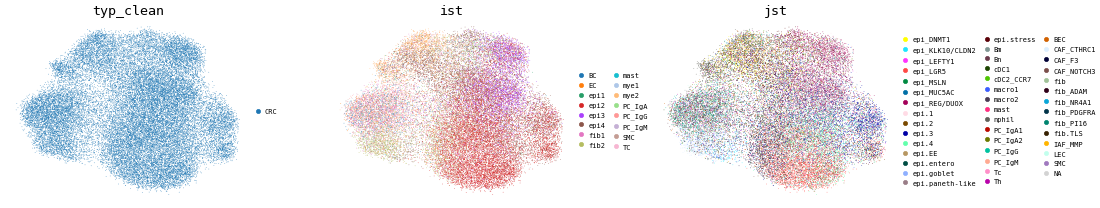

In [45]:
plot_custom_umap(
    adata_crc, subsample=0.1, use_rep='cellina_spatial', color=['typ_clean', 'ist', 'jst'], frameon=False, vmin=-1, vmax=1, wspace=0.2
)

In [46]:
module_scores_epi = module_scores.loc[adata_crc.obs_names]

In [47]:
adata_crc.obsm['module_scores'] = module_scores_epi.values

In [48]:
top_modules = module_scores.idxmax(axis=1)

# Add to adata.obs
adata_crc.obs["top_module"] = top_modules.astype(str)
adata_crc.obs["top_module"] = adata_crc.obs["top_module"].astype("category")

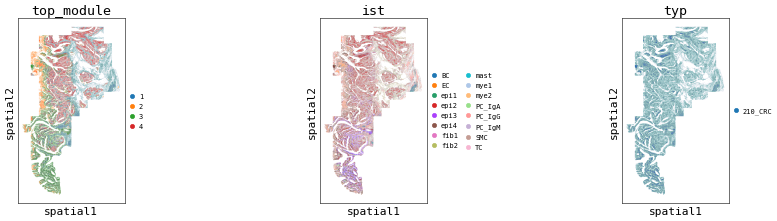

In [49]:
# Plot
sc.pl.spatial(
    adata_crc,
    color=["top_module", "ist", "typ"],
    palette=None,
    spot_size=50,
    show=True
)

In [50]:
# top module to f{CRC{}}
adata_crc.obs['microenvironment'] = adata_crc.obs['top_module'].apply(lambda x: f"CRC{x}")

In [51]:
adata_crc.obs['microenvironment'].value_counts()

microenvironment
CRC4    105796
CRC3     96785
CRC1     93853
CRC2     34954
Name: count, dtype: int64

### Remap

In [52]:
typ_map = adata_crc.obs['microenvironment'].astype(str).reindex(adata_sub.obs_names)  # NaN for non-CRC cells

adata_sub.obs['microenvironment'] = pd.Categorical(
    typ_map.fillna(adata_sub.obs['typ'].astype(str))
)

typ_map = adata_crc.obs['microenvironment'].astype(str).reindex(adata.obs_names)  # NaN for non-CRC cells
adata.obs['microenvironment'] = pd.Categorical(
    typ_map.fillna(adata.obs['typ'].astype(str))
)
    

In [53]:
adata.obs['microenvironment'].value_counts()

microenvironment
210_TVA    185092
CRC4       105796
CRC3        96785
CRC1        93853
210_REF     35761
CRC2        34954
Name: count, dtype: int64

/tmp/ipykernel_1024207/333694513.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  celltype_microenv_counts = adata.obs.groupby([labels_key, 'microenvironment']).size().reset_index(name='count')


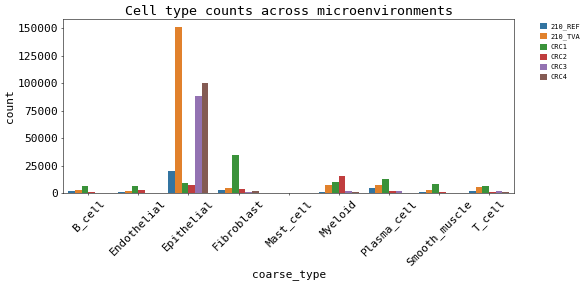

In [54]:
# Plot how many cells of each microenvironment are present in each cell type
celltype_microenv_counts = adata.obs.groupby([labels_key, 'microenvironment']).size().reset_index(name='count')
plt.figure(figsize=(12, 6))
sns.barplot(data=celltype_microenv_counts, x=labels_key, y='count', hue='microenvironment')
plt.xticks(rotation=45)
plt.title("Cell type counts across microenvironments")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Counterfactuals - CRC_global vs. CRC_microenv

In [55]:
celltypes = ['Endothelial', 'Epithelial', 'Fibroblast', 'Myeloid', 'T_cell']
microenvironments = [m for m in adata.obs['microenvironment'].unique() if 'CRC' in m]
results = {k: adata[adata.obs[labels_key] == k] for k in celltypes}

In [56]:
print(microenvironments)

['CRC3', 'CRC2', 'CRC1', 'CRC4']


In [57]:
for ct in tqdm(celltypes, desc=f"Cell types"):
    # Control set is same - only target changes (either crc_all or microenv labels)
    is_tumor_region = adata.obs[domains_key].astype(str).str.contains('CRC', regex=True)
    is_celltype = adata.obs[labels_key].astype(str) == ct
    
    mask_control = ~is_tumor_region & is_celltype
    # mask_control = adata.obs[domains_key].astype(str).str.contains('REF', regex=True) & is_celltype # NOTE: changed from ~CRC to REF
    
    idx_control = np.where(mask_control.values)[0]

    # 1. Compute counterfactuals for global crc
    mask_target = is_tumor_region
    #mask_target = is_tumor_region & is_celltype
    idx_target = np.where(mask_target.values)[0]
    args = {
                # "adata": adata,
                "indices": idx_control,
                "neighbour_indices": idx_target,
                "batch_size": 1024,
                "seed": 0,
                # 'n_neighbors_per_seed':20
            }
    results[ct].obsm['recon_x'] = model.get_normalized_expression(adata=results[ct], batch_size=1024, library_size=1e4)
    results[ct].uns[f'counterfactual_x_global'] = model.get_counterfactual_expression(**args, library_size=1e4)
    results[ct].uns[f'counterfactual_latents_global'] = model.get_counterfactual_latents(**args, latent_key='shifted')

    # 2. Loop over microenvironments
    for microenv in tqdm(microenvironments, desc=f"Microenvironments"):
        is_in_microenv = adata.obs['microenvironment'].astype(str).str.contains(microenv, regex=True)
        mask_target = is_in_microenv
        #mask_target = is_in_microenv & is_celltype
        idx_target = np.where(mask_target.values)[0]
        args["neighbour_indices"] = idx_target
        results[ct].uns[f'counterfactual_x_{microenv}'] = model.get_counterfactual_expression(**args, library_size=1e4)
        results[ct].uns[f'counterfactual_latents_{microenv}'] = model.get_counterfactual_latents(**args, latent_key='shifted')

Cell types:   0%|          | 0/5 [00:00<?, ?it/s]

INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


...

/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)
Cell types: 100%|██████████| 5/5 [01:10<00:00, 14.10s/it]


In [58]:
# _normalize_counts, safe_log2_fold_change, compute_correlations imported from helpers (cell 2)


In [59]:
summary = []
deg = 200

for ct, dataset in tqdm(results.items(), desc="Computing correlations"):
    is_tumor_region = adata.obs[domains_key].astype(str).str.contains('CRC', regex=True)
    mask_control = ~dataset.obs[domains_key].astype(str).str.contains('CRC', regex=True)
    # mask_control = dataset.obs[domains_key].astype(str).str.contains('REF', regex=True) # NOTE: change from ~CRC to REF?

    control = dataset.layers['counts'].todense()[mask_control]
    control = np.asarray(control)
    
    is_ct = dataset.obs[labels_key].astype(str) == ct
    #mask_target = is_tumor_region & is_ct
    mask_target = is_tumor_region
    target = adata.layers['counts'].todense()[mask_target]
    target = np.asarray(target)

    counterfactual = dataset.uns['counterfactual_x_global']
    pear_global, spear_global = compute_correlations(control, target, counterfactual, deg=deg)

    summary.append({
        "cell_type": ct,
        "label": "CRC_global",
        "pearson": np.round(pear_global, 4),
        "spearman": np.round(spear_global, 4)
    })

    for microenv in tqdm(microenvironments, desc="Microenvironments"):
        is_in_microenv = adata.obs['microenvironment'].astype(str).str.contains(microenv, regex=True)
        
        #mask_target = is_in_microenv & is_ct
        mask_target = is_in_microenv
        target = adata.layers['counts'].todense()[mask_target]

        target = np.asarray(target)
        counterfactual = dataset.uns[f'counterfactual_x_{microenv}']
        pear_microenv, spear_microenv = compute_correlations(control, target, counterfactual, deg=deg)
        summary.append({
            "cell_type": ct,
            "label": microenv,
            "pearson": np.round(pear_microenv, 4),
            "spearman": np.round(spear_microenv, 4)
        })

Computing correlations:   0%|          | 0/5 [00:00<?, ?it/s]

Computing correlations: 100%|██████████| 5/5 [02:09<00:00, 25.84s/it]


In [60]:
summary_df = pd.DataFrame(summary)

In [61]:
print(summary_df)

      cell_type       label  pearson  spearman
0   Endothelial  CRC_global   0.6648    0.6734
1   Endothelial        CRC3   0.6637    0.5551
2   Endothelial        CRC2   0.8697    0.8310
3   Endothelial        CRC1   0.8259    0.6965
4   Endothelial        CRC4   0.6419    0.4923
5    Epithelial  CRC_global   0.8205    0.7626
6    Epithelial        CRC3   0.9249    0.8830
7    Epithelial        CRC2   0.7755    0.6758
8    Epithelial        CRC1   0.8151    0.8632
9    Epithelial        CRC4   0.9527    0.9135
10   Fibroblast  CRC_global   0.7564    0.7585
11   Fibroblast        CRC3   0.6682    0.5938
12   Fibroblast        CRC2   0.8889    0.8732
13   Fibroblast        CRC1   0.9119    0.8527
14   Fibroblast        CRC4   0.6450    0.6510
15      Myeloid  CRC_global   0.4204    0.3782
16      Myeloid        CRC3   0.4952    0.5118
17      Myeloid        CRC2   0.9054    0.8877
18      Myeloid        CRC1   0.6754    0.6501
19      Myeloid        CRC4   0.4187    0.2905
20       T_ce

In [62]:
#       cell_type       label  pearson  spearman
# 0   Endothelial  CRC_global   0.8674    0.8235
# 1   Endothelial        CRC3   0.8049    0.8018
# 2   Endothelial        CRC1   0.8987    0.8485
# 3   Endothelial        CRC2   0.8930    0.7733
# 4    Epithelial  CRC_global   0.5855    0.4021
# 5    Epithelial        CRC3   0.5514    0.4841
# 6    Epithelial        CRC1   0.4429    0.2696
# 7    Epithelial        CRC2   0.7729    0.7457
# 8    Fibroblast  CRC_global   0.7642    0.7131
# 9    Fibroblast        CRC3   0.5154    0.6044
# 10   Fibroblast        CRC1   0.8098    0.7559
# 11   Fibroblast        CRC2   0.8318    0.7947
# 12      Myeloid  CRC_global   0.8372    0.7342
# 13      Myeloid        CRC3   0.7298    0.6166
# 14      Myeloid        CRC1   0.8691    0.8055
# 15      Myeloid        CRC2   0.8219    0.7338
# 16       T_cell  CRC_global   0.9485    0.8917
# 17       T_cell        CRC3   0.8497    0.8427
# 18       T_cell        CRC1   0.9558    0.8978
# 19       T_cell        CRC2   0.9437    0.8336

In [63]:
# Save df
summary_df.to_csv(f"../../results/microenvironments_{slide_id}.csv", index=False)

## Save outputs

In [64]:
# ── Save Part 1 outputs ────────────────────────────────────────────────────
import pickle, os

os.makedirs("output", exist_ok=True)

# Save annotated AnnData (includes obsm latents + obs microenvironment)
adata.write_h5ad("output/adata_with_microenv.h5ad")
print("Saved adata to output/adata_with_microenv.h5ad")

# Save Hotspot object (modules, results, etc.)
with open("output/hotspot.pkl", "wb") as _f:
    pickle.dump(hs, _f)
print("Saved hotspot to output/hotspot.pkl")

# Save per-cell-type results dict (AnnData objects with .uns counterfactuals)
with open("output/results.pkl", "wb") as _f:
    pickle.dump(results, _f)
print("Saved results dict to output/results.pkl")

print(f"Model checkpoint saved at: {model_base_path}")


Saved adata to output/adata_with_microenv.h5ad
Saved hotspot to output/hotspot.pkl
Saved results dict to output/results.pkl
Model checkpoint saved at: ./crc_210
